# Step 2 — Forecasting Models: Naive, ARIMA, LSTM (90-day / 3-month horizon)

This notebook picks up where `01_data_preprocessing_eda.ipynb` left off. It loads `student_data_clean.csv` and:

1. Builds a **per-student, per-target** time series (`Stress_Level_Score`, `Mental_Health_Status_Score`)
2. Splits each series into **train** (everything except the last 90 days) and **test** (last 90 days ≈ 3 months) — this is the forecast horizon your thesis targets
3. Implements **Naive**, **ARIMA**, and **LSTM** forecasters
4. Evaluates each with **RMSE**, matching thesis section 2.1.4 / 3.1
5. Reproduces the RMSE comparison chart (thesis Figure 5) and an actual-vs-predicted chart (thesis Figure 4/6)

> **Before running:** make sure `pip install -r requirements.txt` has been run in your VS Code venv — this notebook needs `statsmodels` and `tensorflow` in addition to `pandas`/`numpy`/`scikit-learn`.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 4)


## 2. Load the cleaned data

In [2]:
DATA_PATH = "../data/processed/student_data_clean.csv"

df = pd.read_csv(DATA_PATH, parse_dates=['Timestamp'])
df = df.sort_values(['StudentID', 'Timestamp']).reset_index(drop=True)
print(df.shape)
df[['StudentID', 'Timestamp', 'Stress_Level_Score', 'Mental_Health_Status_Score']].head()


(38650, 17)


,StudentID,Timestamp,Stress_Level_Score,Mental_Health_Status_Score
0,1,2015-01-01,1,0
1,1,2015-01-02,1,1
2,1,2015-01-03,1,5
3,1,2015-01-04,1,5
4,1,2015-01-05,1,5


## 3. Forecast configuration

- **HORIZON = 90** days — matches the thesis's 3-month forecast target.
- We forecast **`Mental_Health_Status_Score`** as the primary target (this is the "Depression/Anxiety" signal your app displays). You can switch `TARGET` to `Stress_Level_Score` and re-run everything below to get that version too — the code is written to work for either.
- We treat each student as its **own** time series (per-student modeling), consistent with the thesis's "Student 3", "Student 6", "Student 8" per-student plots.

In [3]:
TARGET = "Mental_Health_Status_Score"   # or "Stress_Level_Score"
HORIZON = 90
STUDENT_IDS = sorted(df['StudentID'].unique())
print(STUDENT_IDS)


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## 4. Train/test split helper

For each student: everything except the last 90 days = train, last 90 days = test.

In [4]:
def get_series(sid, target=TARGET):
    s = (df[df['StudentID'] == sid]
         .sort_values('Timestamp')
         .set_index('Timestamp')[target]
         .astype(float))
    return s

def train_test_split_series(s, horizon=HORIZON):
    return s.iloc[:-horizon], s.iloc[-horizon:]

# quick check on one student
s = get_series(1)
train, test = train_test_split_series(s)
print(f"Student 1 -> train: {len(train)} days, test: {len(test)} days")
print(f"Train ends: {train.index.max().date()}  |  Test range: {test.index.min().date()} to {test.index.max().date()}")


Student 1 -> train: 3775 days, test: 90 days
Train ends: 2025-05-02  |  Test range: 2025-05-03 to 2025-07-31


## 5. Model 1 — Naive forecast (baseline)

Assumes the future stays at the last observed value. This is the reference every other model must beat, exactly as in the thesis (2.1.3).

In [5]:
def naive_forecast(train, horizon=HORIZON):
    last_value = train.iloc[-1]
    return np.full(horizon, last_value)


## 6. Model 2 — ARIMA

A simple, fixed-order ARIMA(2,1,2) per student. (For a more rigorous thesis writeup you could grid-search `(p,d,q)` with `auto_arima` from `pmdarima`, but a fixed reasonable order is fine to get comparable results across all 10 students without a long search.)

In [6]:
def arima_forecast(train, horizon=HORIZON, order=(2, 1, 2)):
    model = ARIMA(train.values, order=order)
    fitted = model.fit()
    forecast = fitted.forecast(steps=horizon)
    return np.asarray(forecast)


## 7. Model 3 — LSTM

Steps:
1. Scale the series to [0, 1] (LSTMs train better on scaled data)
2. Build sliding windows: use the last `LOOK_BACK` days to predict the next day
3. Train an LSTM on the windows
4. Forecast 90 days **recursively**: predict day 1, feed that prediction back in as if it were real, predict day 2, and so on — this is how a real deployment would work, since you don't have the true future values.

In [7]:
from sklearn.preprocessing import MinMaxScaler

LOOK_BACK = 30  # use the past 30 days to predict the next day

def make_windows(values, look_back=LOOK_BACK):
    X, y = [], []
    for i in range(len(values) - look_back):
        X.append(values[i:i + look_back])
        y.append(values[i + look_back])
    return np.array(X), np.array(y)

def build_lstm(look_back=LOOK_BACK):
    model = Sequential([
        LSTM(32, input_shape=(look_back, 1)),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def lstm_forecast(train, horizon=HORIZON, look_back=LOOK_BACK, epochs=30):
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()

    X, y = make_windows(scaled, look_back)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    model = build_lstm(look_back)
    es = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
    model.fit(X, y, epochs=epochs, batch_size=32, verbose=0, callbacks=[es])

    # recursive forecasting
    window = list(scaled[-look_back:])
    preds_scaled = []
    for _ in range(horizon):
        x_input = np.array(window[-look_back:]).reshape((1, look_back, 1))
        next_val = model.predict(x_input, verbose=0)[0, 0]
        preds_scaled.append(next_val)
        window.append(next_val)

    preds_scaled = np.array(preds_scaled).reshape(-1, 1)
    preds = scaler.inverse_transform(preds_scaled).flatten()
    return preds, model


## 8. Run all three models for every student

This trains a fresh ARIMA and LSTM per student (10 students total). LSTM training will take a few minutes — this is expected.

In [8]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = []       # RMSE table
predictions = {}   # keep raw predictions per student for plotting later

for sid in STUDENT_IDS:
    s = get_series(sid)
    train, test = train_test_split_series(s)

    naive_pred = naive_forecast(train)
    arima_pred = arima_forecast(train)
    lstm_pred, _ = lstm_forecast(train)

    predictions[sid] = {
        'test': test,
        'naive': naive_pred,
        'arima': arima_pred,
        'lstm': lstm_pred,
    }

    for name, pred in [('Naive', naive_pred), ('ARIMA', arima_pred), ('LSTM', lstm_pred)]:
        results.append({
            'StudentID': sid,
            'Model': name,
            'RMSE': rmse(test.values, pred),
            'MAE': mean_absolute_error(test.values, pred),
        })
    print(f"Student {sid} done.")

results_df = pd.DataFrame(results)
results_df


Student 1 done.
Student 2 done.
Student 3 done.
Student 4 done.
Student 5 done.
Student 6 done.
Student 7 done.
Student 8 done.
Student 9 done.
Student 10 done.


,StudentID,Model,RMSE,MAE
0,1,Naive,0.714920,0.511111
1,1,ARIMA,0.664845,0.531434
2,1,LSTM,0.633810,0.563273
3,2,Naive,1.598611,1.333333
4,2,ARIMA,0.892389,0.759422
5,2,LSTM,1.223118,0.992409
6,3,Naive,1.290994,0.888889
7,3,ARIMA,1.287716,0.889549
8,3,LSTM,1.052365,0.930941
9,4,Naive,0.823273,0.588889


## 9. Model comparison — average RMSE across all students

This reproduces thesis **Figure 5 (Model Comparison – RMSE)**, but averaged across all 10 students rather than a single one.

           RMSE       MAE
Model                    
Naive  1.228064  0.924444
ARIMA  0.964429  0.765466
LSTM   0.933508  0.776562


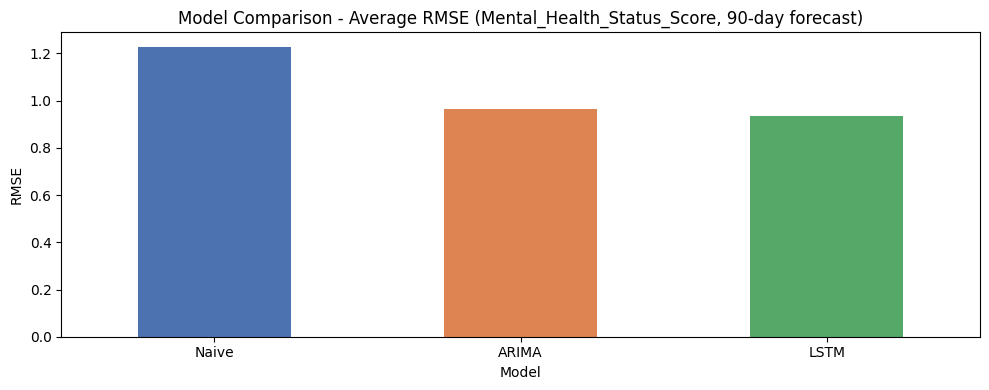

In [9]:
summary = results_df.groupby('Model')[['RMSE', 'MAE']].mean().reindex(['Naive', 'ARIMA', 'LSTM'])
print(summary)

fig, ax = plt.subplots()
summary['RMSE'].plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title(f'Model Comparison - Average RMSE ({TARGET}, {HORIZON}-day forecast)')
ax.set_ylabel('RMSE')
ax.set_xticklabels(summary.index, rotation=0)
plt.tight_layout()
plt.show()


## 10. Actual vs Predicted — one student

Reproduces thesis **Figure 6 (Stress Level Score, Actual vs Predicted over Forecast Horizon)** style plot. Change `sid` to inspect a different student.

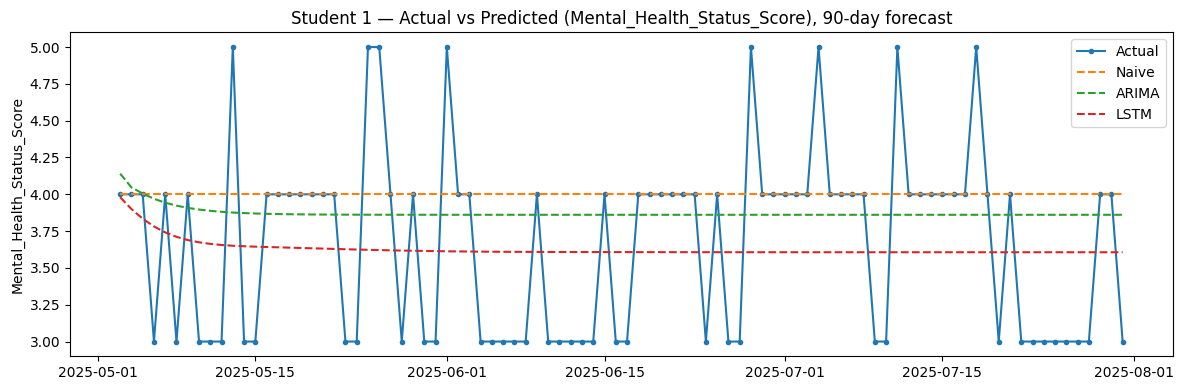

In [10]:
sid = STUDENT_IDS[0]
p = predictions[sid]

fig, ax = plt.subplots(figsize=(12, 4))
test_index = p['test'].index
ax.plot(test_index, p['test'].values, label='Actual', marker='o', markersize=3)
ax.plot(test_index, p['naive'], label='Naive', linestyle='--')
ax.plot(test_index, p['arima'], label='ARIMA', linestyle='--')
ax.plot(test_index, p['lstm'], label='LSTM', linestyle='--')
ax.set_title(f'Student {sid} — Actual vs Predicted ({TARGET}), {HORIZON}-day forecast')
ax.set_ylabel(TARGET)
ax.legend()
plt.tight_layout()
plt.show()


## 11. Save results

Save the RMSE/MAE table and the per-student predictions so you can use them in your report (tables, charts) without re-running the models.

In [11]:
results_df.to_csv("model_comparison_results.csv", index=False)
print("Saved model_comparison_results.csv")
results_df.groupby('Model')[['RMSE', 'MAE']].agg(['mean', 'std'])


Saved model_comparison_results.csv


RMSE                 MAE          
           mean       std      mean       std
Model                                        
ARIMA  0.964429  0.265629  0.765466  0.195405
LSTM   0.933508  0.197183  0.776562  0.172833
Naive  1.228064  0.327116  0.924444  0.312247

## What's next

- If **LSTM doesn't clearly beat ARIMA/Naive** on your run, that's a legitimate and reportable finding — not every dataset favors deep learning, and your thesis discussion (3.3) can note this alongside the tradeoffs (LSTM needs more compute, less interpretable, etc.)
- To classify the numeric forecast back into a human-readable category (e.g. "Depression", "Medium"), round the predicted score to the nearest integer and map it back through the same `mh_order` / `stress_order` list from notebook 1.
- Next step after this: wire the trained model into your FastAPI backend (`Table III` in your thesis) so the mobile app can call it — happy to help scaffold that endpoint when you're ready.
